# 01 — Exploratory data analysis

This notebook explores the MCQ dataset and saves feature files that the model notebooks use later. Each visualization is in its own small cell so we can walk through them individually.

## Setup

In [1]:
import subprocess, sys
for pkg in ['sentence-transformers', 'pyarrow']:
    try: __import__(pkg.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [2]:
import os
from pathlib import Path

IS_KAGGLE = os.path.exists("/kaggle/input")

if IS_KAGGLE:
    DATA_DIR = Path("/kaggle/input/competitions/smart-mcq-solver-challenge")
    OUTPUT_DIR = Path("/kaggle/working")
    PREDICTIONS_DIR = OUTPUT_DIR / "predictions"
    FEATURES_DIR = OUTPUT_DIR / "features"
    FIGURES_DIR = OUTPUT_DIR / "figures"
else:
    ROOT = Path.cwd()
    if ROOT.name == "notebooks":
        ROOT = ROOT.parent
    DATA_DIR = ROOT / "data"
    PREDICTIONS_DIR = ROOT / "predictions"
    FEATURES_DIR = ROOT / "features"
    FIGURES_DIR = ROOT / "figures"

for p in [PREDICTIONS_DIR, FEATURES_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"IS_KAGGLE={IS_KAGGLE}")
print(f"DATA_DIR={DATA_DIR}")

IS_KAGGLE=False
DATA_DIR=c:\Users\Krishna\Downloads\dl-genai-t22026-23f2001849\data


In [3]:
import re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

random.seed(42); np.random.seed(42)
sns.set_style('whitegrid')
OPTIONS = ['A', 'B', 'C', 'D', 'E']

## Load data

In [4]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
print(f'train: {train.shape}')
print(f'test: {test.shape}')
train.head(3)

train: (2000, 8)
test: (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


## Plot 1: answer letter distribution

How often is each option (A-E) the correct answer? We want to see if there's a positional bias.

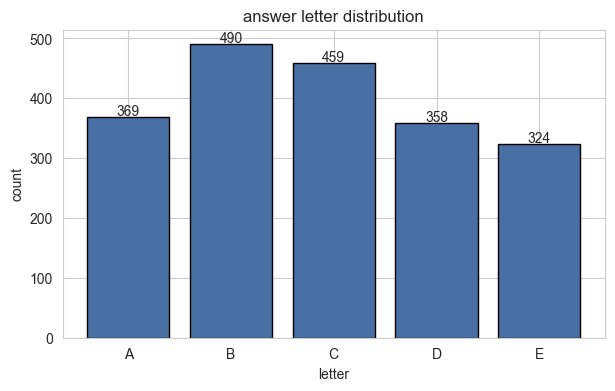

In [5]:
counts = train['answer'].value_counts().reindex(OPTIONS)

plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color='#4A6FA5', edgecolor='black')
for i, v in enumerate(counts.values):
    plt.text(i, v + 3, str(v), ha='center', fontsize=10)
plt.title('answer letter distribution')
plt.xlabel('letter'); plt.ylabel('count')
plt.savefig(FIGURES_DIR / '01_answer_dist.png', dpi=110, bbox_inches='tight')
plt.show()

## Plot 2: prompt length (characters)

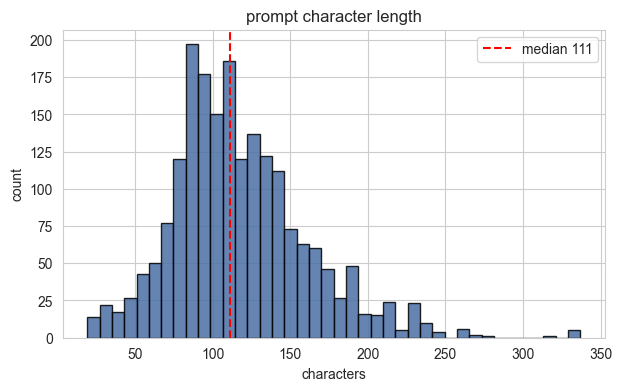

In [6]:
prompt_chars = train['prompt'].str.len()

plt.figure(figsize=(7, 4))
plt.hist(prompt_chars, bins=40, color='#4A6FA5', edgecolor='black', alpha=0.85)
plt.axvline(prompt_chars.median(), color='red', ls='--', label=f'median {int(prompt_chars.median())}')
plt.title('prompt character length')
plt.xlabel('characters'); plt.ylabel('count'); plt.legend()
plt.savefig(FIGURES_DIR / '02_prompt_chars.png', dpi=110, bbox_inches='tight')
plt.show()

## Plot 3: prompt length (words)

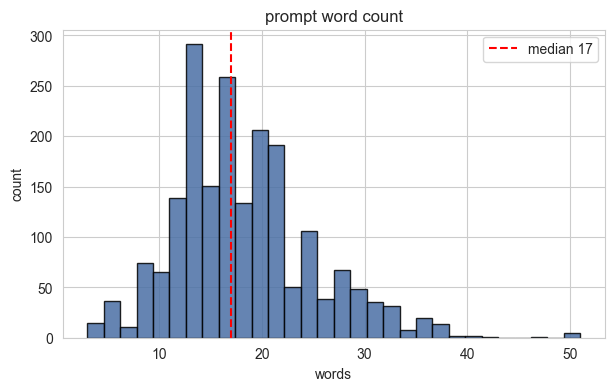

In [7]:
prompt_words = train['prompt'].str.split().map(len)

plt.figure(figsize=(7, 4))
plt.hist(prompt_words, bins=30, color='#4A6FA5', edgecolor='black', alpha=0.85)
plt.axvline(prompt_words.median(), color='red', ls='--', label=f'median {int(prompt_words.median())}')
plt.title('prompt word count')
plt.xlabel('words'); plt.ylabel('count'); plt.legend()
plt.savefig(FIGURES_DIR / '03_prompt_words.png', dpi=110, bbox_inches='tight')
plt.show()

## Plot 4: option length by position

Is the length of an option related to which letter position it appears in?

C:\Users\Krishna\AppData\Local\Temp\ipykernel_32824\3490632420.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(option_lengths, labels=OPTIONS)


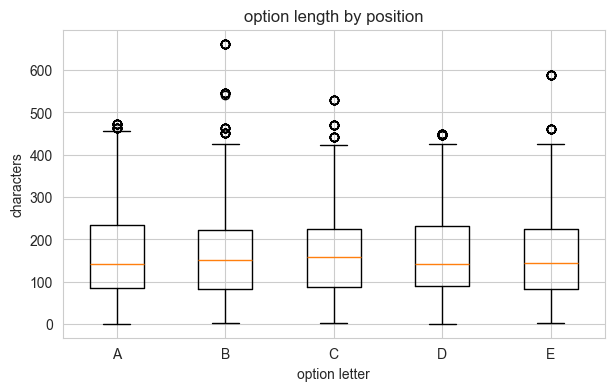

In [8]:
option_lengths = [train[L].astype(str).str.len().tolist() for L in OPTIONS]

plt.figure(figsize=(7, 4))
plt.boxplot(option_lengths, labels=OPTIONS)
plt.title('option length by position')
plt.xlabel('option letter'); plt.ylabel('characters')
plt.savefig(FIGURES_DIR / '04_option_by_position.png', dpi=110, bbox_inches='tight')
plt.show()

## Plot 5: correct vs wrong option length

Are correct answers systematically longer? This is a well-known signal in MCQ tasks.

In [9]:
correct_lens = []
wrong_lens = []
for _, row in train.iterrows():
    for L in OPTIONS:
        length = len(str(row[L]))
        if L == row['answer']:
            correct_lens.append(length)
        else:
            wrong_lens.append(length)

print(f'mean correct length: {np.mean(correct_lens):.1f}')
print(f'mean wrong length:   {np.mean(wrong_lens):.1f}')

mean correct length: 181.9
mean wrong length:   160.7


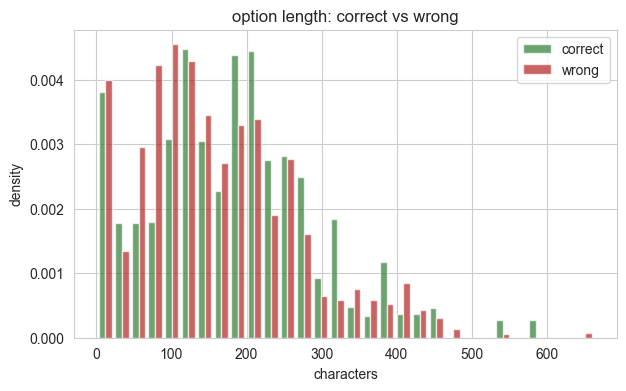

In [10]:
plt.figure(figsize=(7, 4))
plt.hist([correct_lens, wrong_lens], bins=30, label=['correct', 'wrong'],
         color=['#2E7D32', '#B22222'], alpha=0.7, density=True)
plt.title('option length: correct vs wrong')
plt.xlabel('characters'); plt.ylabel('density'); plt.legend()
plt.savefig(FIGURES_DIR / '05_correct_vs_wrong_len.png', dpi=110, bbox_inches='tight')
plt.show()

## Plot 6: is the longest option the correct one?

In [11]:
matches = 0
for _, row in train.iterrows():
    lengths = {L: len(str(row[L])) for L in OPTIONS}
    longest = max(lengths, key=lengths.get)
    if longest == row['answer']:
        matches += 1

pct = 100 * matches / len(train)
print(f'longest option is correct in {pct:.1f}% of questions')

longest option is correct in 40.5% of questions


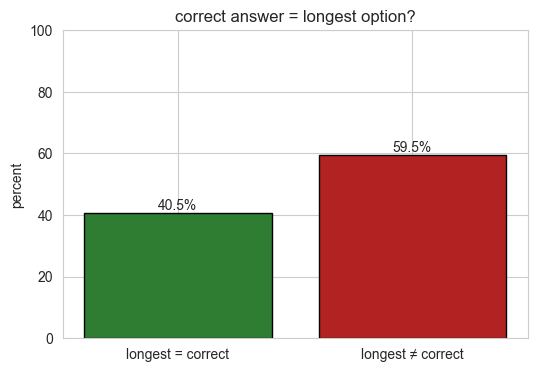

In [12]:
plt.figure(figsize=(6, 4))
plt.bar(['longest = correct', 'longest ≠ correct'], [pct, 100 - pct],
        color=['#2E7D32', '#B22222'], edgecolor='black')
for i, v in enumerate([pct, 100 - pct]):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.title('correct answer = longest option?')
plt.ylabel('percent'); plt.ylim(0, 100)
plt.savefig(FIGURES_DIR / '06_longest_correct.png', dpi=110, bbox_inches='tight')
plt.show()

## Prompt framing patterns

The prompts often start or end with reusable phrases (`Pick the best...`, `...from the following choices.`). If we strip these, paraphrases of the same underlying question collapse to a shared stem. We use that stem later for GroupKFold splits.

In [13]:
PREFIX_PATTERNS = [
    r'^\s*pick the best possible answer\s*[:\-]?\s*',
    r'^\s*select the most accurate option\s*[:\-]?\s*',
    r'^\s*determine the correct option\s*[:\-]?\s*',
    r'^\s*identify the correct statement\s*[:\-]?\s*',
    r'^\s*choose the correct answer\s*[:\-]?\s*',
    r'^\s*which of the following is correct\??\s*',
]
SUFFIX_PATTERNS = [
    r'\s+based on the given context\.?\s*$',
    r'\s+based on the given information\.?\s*$',
    r'\s+from the following choices\.?\s*$',
    r'\s+among the listed options\.?\s*$',
    r'\s+carefully\.?\s*$',
    r'\s+above\.?\s*$',
]

In [14]:
def strip_framing(text):
    text = str(text)
    prev = None
    while prev != text:
        prev = text
        for p in PREFIX_PATTERNS:
            text = re.sub(p, '', text, flags=re.IGNORECASE)
        for p in SUFFIX_PATTERNS:
            text = re.sub(p, '', text, flags=re.IGNORECASE)
    return re.sub(r'\s+', ' ', text).strip().lower()

In [15]:
train['stem'] = train['prompt'].apply(strip_framing)
test['stem'] = test['prompt'].apply(strip_framing)
print(f'unique prompts (train): {train["prompt"].nunique()}')
print(f'unique stems (train):   {train["stem"].nunique()}')
print(f'unique stems (test):    {test["stem"].nunique()}')

unique prompts (train): 1758
unique stems (train):   252
unique stems (test):    228


## Plot 7: character savings after stripping framing

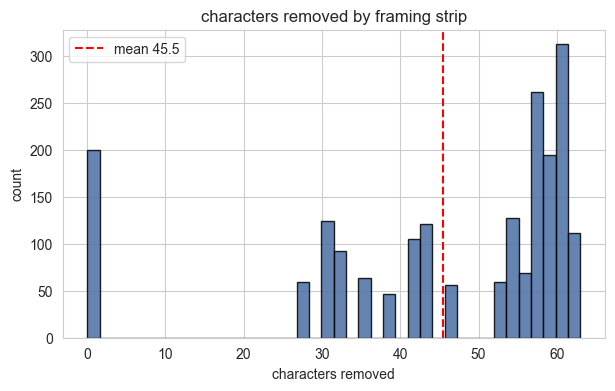

In [16]:
chars_saved = train['prompt'].str.len() - train['stem'].str.len()

plt.figure(figsize=(7, 4))
plt.hist(chars_saved, bins=40, color='#4A6FA5', edgecolor='black', alpha=0.85)
plt.axvline(chars_saved.mean(), color='red', ls='--',
            label=f'mean {chars_saved.mean():.1f}')
plt.title('characters removed by framing strip')
plt.xlabel('characters removed'); plt.ylabel('count'); plt.legend()
plt.savefig(FIGURES_DIR / '07_chars_stripped.png', dpi=110, bbox_inches='tight')
plt.show()

## Convert to long format

Instead of one row per question with 5 option columns, we build one row per (question, option) pair. This gives 2000 × 5 = 10000 rows for train. Model 1 (LR), Model 2 (CNN), Model 3 (Bi-LSTM), and LightGBM all operate on this format.

In [17]:
def to_long(df, has_answer=True):
    rows = []
    for _, r in df.iterrows():
        for L in OPTIONS:
            row = {'id': r['id'], 'prompt': r['prompt'], 'stem': r['stem'],
                   'option': str(r[L]), 'letter': L,
                   'letter_idx': OPTIONS.index(L)}
            if has_answer:
                row['is_correct'] = int(L == r['answer'])
            rows.append(row)
    return pd.DataFrame(rows)

train_long = to_long(train, has_answer=True)
test_long = to_long(test, has_answer=False)
print(f'train_long: {train_long.shape}')
print(f'test_long:  {test_long.shape}')

train_long: (10000, 7)
test_long:  (2500, 6)


## Handcrafted features (per option)

These are basic descriptive statistics about each option.

In [18]:
def add_features(df):
    df = df.copy()
    df['opt_chars'] = df['option'].str.len().astype(float)
    df['opt_words'] = df['option'].str.split().map(len).astype(float)
    return df

train_long = add_features(train_long)
test_long = add_features(test_long)

In [19]:
# ranks and z-scores within each question
for df in [train_long, test_long]:
    g = df.groupby('id')
    df['chars_ratio_max'] = df['opt_chars'] / g['opt_chars'].transform('max').clip(lower=1)
    df['chars_rank'] = g['opt_chars'].rank(ascending=False, method='min')
    df['chars_zscore'] = ((df['opt_chars'] - g['opt_chars'].transform('mean'))
                          / g['opt_chars'].transform('std').clip(lower=1e-6))
    df['is_longest'] = (df['opt_chars'] == g['opt_chars'].transform('max')).astype(float)
    df['is_shortest'] = (df['opt_chars'] == g['opt_chars'].transform('min')).astype(float)

In [20]:
# keyword flags
for df in [train_long, test_long]:
    text = df['option'].astype(str).str.lower()
    df['has_not']    = text.str.contains(r'\bnot\b', regex=True).astype(float)
    df['has_except'] = text.str.contains(r'\bexcept\b', regex=True).astype(float)
    df['has_only']   = text.str.contains(r'\bonly\b', regex=True).astype(float)
    df['has_all']    = text.str.contains(r'\ball\b', regex=True).astype(float)
    df['has_none']   = text.str.contains(r'\bnone\b', regex=True).astype(float)
    df['n_numbers']  = df['option'].apply(lambda s: len(re.findall(r'\d+', str(s)))).astype(float)
    df['position']   = df['letter_idx'].astype(float)

## TF-IDF prompt–option similarity

How similar is the option to the prompt in word or character space? A correct option usually shares vocabulary with the prompt.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# fit on all text (both train and test)
all_text = (train['prompt'].tolist() + test['prompt'].tolist()
            + train_long['option'].tolist() + test_long['option'].tolist())

tf_word = TfidfVectorizer(ngram_range=(1, 2), max_features=50_000, sublinear_tf=True)
tf_word.fit(all_text)
print(f'word vocab: {len(tf_word.vocabulary_)}')

word vocab: 12749


In [22]:
def tfidf_cosine(df, vectorizer):
    P = vectorizer.transform(df['prompt'].astype(str))
    O = vectorizer.transform(df['option'].astype(str))
    dot = np.asarray(P.multiply(O).sum(1)).ravel()
    pn = np.sqrt(np.asarray(P.multiply(P).sum(1)).ravel()).clip(min=1e-9)
    on = np.sqrt(np.asarray(O.multiply(O).sum(1)).ravel()).clip(min=1e-9)
    return dot / (pn * on)

train_long['tfidf_cos'] = tfidf_cosine(train_long, tf_word)
test_long['tfidf_cos'] = tfidf_cosine(test_long, tf_word)

## Plot 8: TF-IDF cosine, correct vs wrong

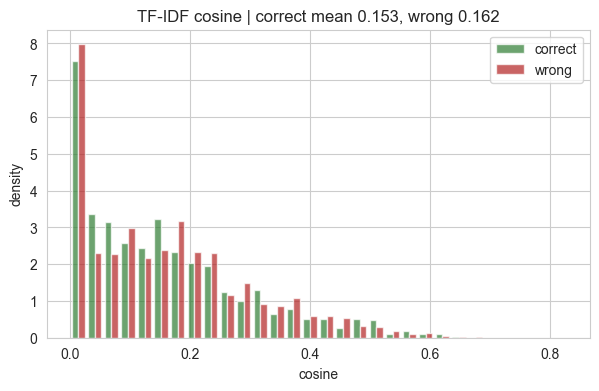

In [23]:
correct = train_long.loc[train_long['is_correct'] == 1, 'tfidf_cos']
wrong = train_long.loc[train_long['is_correct'] == 0, 'tfidf_cos']

plt.figure(figsize=(7, 4))
plt.hist([correct, wrong], bins=30, label=['correct', 'wrong'],
         color=['#2E7D32', '#B22222'], alpha=0.7, density=True)
plt.title(f'TF-IDF cosine | correct mean {correct.mean():.3f}, wrong {wrong.mean():.3f}')
plt.xlabel('cosine'); plt.ylabel('density'); plt.legend()
plt.savefig(FIGURES_DIR / '08_tfidf_cosine.png', dpi=110, bbox_inches='tight')
plt.show()

## Sentence-transformer embeddings

MiniLM-L6-v2 produces 384-dim sentence embeddings. We use the prompt-option cosine as another semantic-similarity feature.

In [24]:
import torch
from sentence_transformers import SentenceTransformer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
sbert = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)
print(f'sbert device: {device}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

sbert device: cpu


In [25]:
print('encoding train prompts...')
train_prompt_embs = sbert.encode(train['prompt'].tolist(), batch_size=64,
                                  convert_to_numpy=True, normalize_embeddings=True,
                                  show_progress_bar=False)
print('encoding test prompts...')
test_prompt_embs = sbert.encode(test['prompt'].tolist(), batch_size=64,
                                 convert_to_numpy=True, normalize_embeddings=True,
                                 show_progress_bar=False)

encoding train prompts...
encoding test prompts...


In [26]:
print('encoding train options...')
train_opt_embs = sbert.encode(train_long['option'].tolist(), batch_size=128,
                               convert_to_numpy=True, normalize_embeddings=True,
                               show_progress_bar=False)
print('encoding test options...')
test_opt_embs = sbert.encode(test_long['option'].tolist(), batch_size=128,
                              convert_to_numpy=True, normalize_embeddings=True,
                              show_progress_bar=False)
print(f'embedding dim: {train_prompt_embs.shape[1]}')

encoding train options...
encoding test options...
embedding dim: 384


In [27]:
# prompt-option cosine (each option compared to its own prompt)
train_prompt_rep = np.repeat(train_prompt_embs, 5, axis=0)
test_prompt_rep = np.repeat(test_prompt_embs, 5, axis=0)
train_long['sbert_cos'] = np.sum(train_prompt_rep * train_opt_embs, axis=1)
test_long['sbert_cos'] = np.sum(test_prompt_rep * test_opt_embs, axis=1)

## Plot 9: SBERT cosine, correct vs wrong

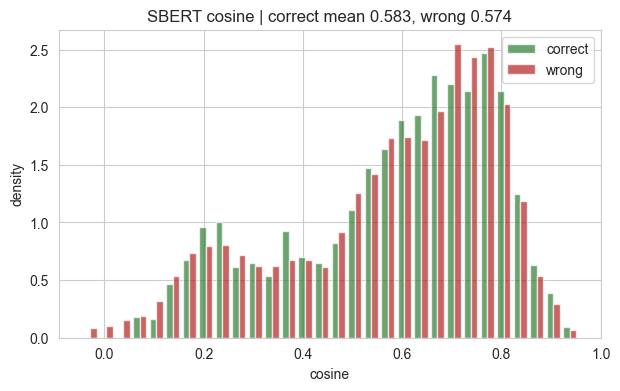

In [28]:
correct = train_long.loc[train_long['is_correct'] == 1, 'sbert_cos']
wrong = train_long.loc[train_long['is_correct'] == 0, 'sbert_cos']

plt.figure(figsize=(7, 4))
plt.hist([correct, wrong], bins=30, label=['correct', 'wrong'],
         color=['#2E7D32', '#B22222'], alpha=0.7, density=True)
plt.title(f'SBERT cosine | correct mean {correct.mean():.3f}, wrong {wrong.mean():.3f}')
plt.xlabel('cosine'); plt.ylabel('density'); plt.legend()
plt.savefig(FIGURES_DIR / '09_sbert_cosine.png', dpi=110, bbox_inches='tight')
plt.show()

## GroupKFold split by stem

We split on `stem` so paraphrases of the same underlying question stay in the same fold. This prevents artificially high validation scores from leakage.

In [29]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
fold_of_id = np.zeros(len(train), dtype=int)
for fold, (_, val_idx) in enumerate(gkf.split(train, groups=train['stem'])):
    fold_of_id[val_idx] = fold
train['fold'] = fold_of_id

id_to_fold = dict(zip(train['id'], train['fold']))
train_long['fold'] = train_long['id'].map(id_to_fold)

print('questions per fold:')
print(train.groupby('fold').size())

questions per fold:
fold
0    400
1    400
2    400
3    400
4    400
dtype: int64


## Plot 10: fold composition

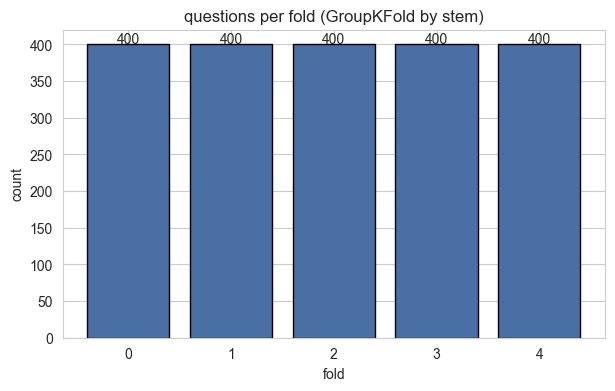

In [30]:
fold_sizes = train.groupby('fold').size()

plt.figure(figsize=(7, 4))
plt.bar(fold_sizes.index, fold_sizes.values, color='#4A6FA5', edgecolor='black')
for i, v in enumerate(fold_sizes.values):
    plt.text(i, v + 1, str(v), ha='center')
plt.title('questions per fold (GroupKFold by stem)')
plt.xlabel('fold'); plt.ylabel('count')
plt.savefig(FIGURES_DIR / '10_fold_sizes.png', dpi=110, bbox_inches='tight')
plt.show()

## Save features for downstream notebooks

In [31]:
FEAT_COLS = [
    'opt_chars', 'opt_words', 'chars_ratio_max', 'chars_rank', 'chars_zscore',
    'is_longest', 'is_shortest', 'has_not', 'has_except', 'has_only',
    'has_all', 'has_none', 'n_numbers', 'position', 'tfidf_cos', 'sbert_cos',
]
print(f'total feature count: {len(FEAT_COLS)}')

total feature count: 16


In [32]:
train_long.to_parquet(FEATURES_DIR / 'train_long.parquet', index=False)
test_long.to_parquet(FEATURES_DIR / 'test_long.parquet', index=False)
train[['id', 'fold', 'stem', 'answer']].to_parquet(FEATURES_DIR / 'train_meta.parquet', index=False)
test[['id', 'stem']].to_parquet(FEATURES_DIR / 'test_meta.parquet', index=False)

import json
with open(FEATURES_DIR / 'feat_cols.json', 'w') as f:
    json.dump({'FEAT_COLS': FEAT_COLS}, f, indent=2)

print(f'saved train_long: {train_long.shape}')
print(f'saved test_long:  {test_long.shape}')

saved train_long: (10000, 24)
saved test_long:  (2500, 22)
